# Détection de fraude financière par raisonnement explicable avec les LLMs: Une approche Chain-of-Thought + RAG vs Machine Learning classique

## 1. Configuration de l'Environnement et Démarrage du Serveur Ollama

In [1]:
# 1. Install the missing system tool (zstd) required by Ollama
!apt-get update -y > /dev/null 2>&1
!apt-get install -y zstd > /dev/null 2>&1

# 2. Install Python packages
!pip install ollama faiss-cpu > /dev/null 2>&1

# 3. Install the Ollama engine for Linux
!curl -fsSL https://ollama.com/install.sh | sh > /dev/null 2>&1

# 4. Start the Ollama server in the background
import subprocess
import time

print("Starting Ollama server...")
# THE FIX: We open a log file and send all outputs there so it never fills up memory!
log_file = open('ollama.log', 'w')
process = subprocess.Popen(['ollama', 'serve'], stdout=log_file, stderr=log_file)

time.sleep(5)
print("Ollama server is running!")

Starting Ollama server...
Ollama server is running!


In [2]:
%%capture
# This will run silently!
# Download the specific models

!ollama pull nomic-embed-text
!ollama pull deepseek-r1

## 2. Imports et initialisation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import ollama
import re

## 3. Chargement et réduction du dataset

In [4]:
df = pd.read_csv("/kaggle/input/datasets/aryan208/financial-transactions-dataset-for-fraud-detection/financial_fraud_detection_dataset.csv")

df.head()
df.info()
df['is_fraud'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64

In [5]:
# Réduction supplémentaire pour le prototypage
df = df.sample(n=1_000_000, random_state=42)
df.reset_index(drop=True, inplace=True)

df.shape

(1000000, 18)

## 4. Agrégations par client (profil + historique)

In [6]:
customer_stats = df.groupby('sender_account').agg(
    amount_mean=('amount', 'mean'),
    amount_max=('amount', 'max'),
    tx_count=('amount', 'count'),
    fraud_count=('is_fraud', 'sum')
).reset_index()

# Taux de fraude historique
customer_stats['fraud_rate'] = (
    customer_stats['fraud_count'] / customer_stats['tx_count']
)

customer_stats.head()


,sender_account,amount_mean,amount_max,tx_count,fraud_count,fraud_rate
0,ACC100005,1492.22,1492.22,1,0,0.0
1,ACC100006,47.57,47.57,1,0,0.0
2,ACC100008,402.71,402.71,1,0,0.0
3,ACC100009,80.68,80.68,1,0,0.0
4,ACC100010,217.34,318.03,2,0,0.0


## 5. Fusion avec le dataset principal

In [7]:
df_merged = df.merge(
    customer_stats,
    on='sender_account',
    how='left'
)

df_merged.head()


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,amount_mean,amount_max,tx_count,fraud_count,fraud_rate
0,T3677888,2023-04-09T20:06:09.254118,ACC529887,ACC346873,11.67,transfer,online,London,pos,False,...,11,0.89,ACH,143.188.216.101,D1912159,199.495000,387.32,2,0,0.0
1,T5093932,2023-07-16T05:26:15.162082,ACC872160,ACC767192,184.31,payment,other,Tokyo,pos,False,...,10,0.65,ACH,147.167.236.198,D5847071,647.593750,2035.98,8,0,0.0
2,T4194900,2023-12-13T19:04:47.539751,ACC403211,ACC536309,930.34,deposit,travel,Toronto,pos,False,...,19,0.40,ACH,83.44.197.232,D2907026,641.365000,930.34,2,1,0.5
3,T4520497,2023-12-15T12:06:09.051479,ACC313245,ACC322871,0.01,withdrawal,restaurant,Berlin,mobile,False,...,14,0.97,UPI,168.84.79.173,D7924413,675.213333,1082.76,3,0,0.0
4,T734465,2023-11-19T21:33:24.238666,ACC570417,ACC246664,131.16,withdrawal,restaurant,Dubai,mobile,False,...,20,0.70,card,128.58.20.122,D5999152,131.160000,131.16,1,0,0.0


## 6. Exemples de cas de fraude / non-fraude

In [8]:
# Sélection équilibrée pour tests LLM
fraud_cases = df_merged[df_merged['is_fraud'] == True].sample(20, random_state=42)
nonfraud_cases = df_merged[df_merged['is_fraud'] == False].sample(30, random_state=42)

cases = pd.concat([fraud_cases, nonfraud_cases]) \
           .sample(frac=1, random_state=42) \
           .reset_index(drop=True)

cases.shape

(50, 23)

In [9]:
# MODE TEST : limiter le nombre d'appels LLM
cases = cases.sample(n=30, random_state=42)
cases.shape

(30, 23)

## 7. RAG avec des fraudes similaires

### Création de représentations textuelles des transactions

In [10]:
def transaction_to_text(row):
    return f"""
Transaction:
- Montant: {row['amount']} USD
- Catégorie: {row.get('merchant_category', 'N/A')}
- Localisation: {row.get('location', 'N/A')}
- Device: {row.get('device_used', 'N/A')}
- Heure: {row.get('timestamp', 'N/A')}
- Moyenne client: {round(row.get('amount_mean', 0), 2)}
- Taux fraude historique: {round(row.get('fraud_rate', 0), 3)}
"""


### Sélection de cas de fraude de référence pour le RAG

In [11]:
fraud_corpus = df_merged[df_merged["is_fraud"] == 1].sample(
    n=20_000, random_state=42
).reset_index(drop=True)


### Génération d'embeddings (compatibles avec Ollama)

In [12]:
def get_embedding(text):
    response = ollama.embeddings(
        model="nomic-embed-text",
        prompt=text
    )
    return response["embedding"]


#### Définition des chemins de cache

In [13]:
import os
import pickle

EMB_PATH = "cache/fraud_embeddings.npy"
TEXT_PATH = "cache/fraud_texts.pkl"

os.makedirs("cache", exist_ok=True)


#### Sauvegarde des embeddings après le premier calcul

In [14]:
from tqdm import tqdm
import time
import pickle
import os
import numpy as np

if not os.path.exists(EMB_PATH):
    print("Computing fraud embeddings (first run)...")
    fraud_texts = fraud_corpus.apply(transaction_to_text, axis=1).tolist()
    
    embeddings = []

    # FIXED: Added mininterval=2.0 so Kaggle's UI only updates every 2 seconds
    for i, text in enumerate(tqdm(fraud_texts, desc="Embedding fraud transactions", mininterval=2.0)):
        try:
            embeddings.append(get_embedding(text))
        except Exception as e:
            print(f"\nEmbedding failed at {i}, retrying once...")
            time.sleep(2) # Wait a bit longer before retrying
            embeddings.append(get_embedding(text))
            
        # FIXED: Pause for 1 second every 500 transactions to prevent Ollama from crashing
        if i > 0 and i % 500 == 0:
            time.sleep(1)

    fraud_embeddings = np.array(embeddings)

    # Save to disk
    np.save(EMB_PATH, fraud_embeddings)
    with open(TEXT_PATH, "wb") as f:
        pickle.dump(fraud_texts, f)

    print("Embeddings cached successfully")

else:
    print("Loading cached fraud embeddings...")
    fraud_embeddings = np.load(EMB_PATH)
    
    with open(TEXT_PATH, "rb") as f:
        fraud_texts = pickle.load(f)

    print("Embeddings loaded from cache")

Computing fraud embeddings (first run)...


Embedding fraud transactions: 100%|██████████| 20000/20000 [08:51<00:00, 37.63it/s]


Embeddings cached successfully


### Reconstruction de l'index FAISS depuis le cache

In [15]:
import faiss
import numpy as np

# FAISS REQUIREMENTS
fraud_embeddings = np.asarray(fraud_embeddings, dtype="float32")

dim = fraud_embeddings.shape[1]

faiss.normalize_L2(fraud_embeddings)

index = faiss.IndexFlatIP(dim)
index.add(fraud_embeddings)

print("FAISS index ready with", index.ntotal, "fraud cases")



FAISS index ready with 20000 fraud cases


### Récupération de fraudes similaires pour une nouvelle transaction

In [16]:
def retrieve_similar_frauds(row, k=3):
    query_text = transaction_to_text(row)

    query_emb = np.array(
        [get_embedding(query_text)],
        dtype="float32"  
    )

    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, k)

    return [fraud_texts[i] for i in indices[0]]



## 8. Imports Ollama et fonction d'appel DeepSeek

In [17]:
import ollama
import re

def call_deepseek_chain_of_thought(context_text):
    response = ollama.chat(
        model="deepseek-r1",
        messages=[
            {"role": "user", "content": context_text}
        ],
    )
    content = response["message"]["content"]
    # DeepSeek R1 renvoie souvent un bloc <think> ... </think> qu'on peut enlever.[web:38]
    final_answer = re.sub(r"<think>.*?</think>", "", content, flags=re.DOTALL).strip()
    return final_answer

## 9. Construction du contexte pour le LLM

In [18]:
def build_context_for_row(row):
    # Profile client
    profil = f"""
Profil client:
- ID client: {row['sender_account']}
- Localisation habituelle: {row.get('location', 'N/A')}
- Nombre total de transactions: {row.get('tx_count', 'N/A')}
- Nombre total de fraudes historiques: {row.get('fraud_count', 'N/A')}
- Montant moyen habituel: {round(row.get('amount_mean', 0), 2)}
"""

    # Transaction courante
    transaction = f"""
Transaction courante:
- Montant: {row['amount']}
- Catégorie marchand: {row.get('merchant_category', 'N/A')}
- Localisation: {row.get('location', 'N/A')}
- Device utilisé: {row.get('device_used', 'N/A')}
- Date/heure: {row.get('timestamp', 'N/A')}
"""

    # Règles métier
    regles = """
Règles métier:
- Si le montant > 5x la moyenne habituelle du client => fortement suspect.
- Si la transaction est effectuée depuis une localisation inhabituelle => suspect.
- Si le client a déjà au moins une fraude historique => risque élevé.
- Si le montant > 5000 USD => vérifier attentivement.
- Si la transaction est effectuée tard dans la nuit (entre 00h et 05h) => augmente le niveau de suspicion.
"""
    # Fraudes similaires (RAG)
    similar_frauds = retrieve_similar_frauds(row, k=3)

    rag_block = "\n".join(
        [f"Exemple {i+1}:\n{ex}" for i, ex in enumerate(similar_frauds)]
    )
    
    # Construction du prompt final
    prompt = f"""
    Tu es un analyste fraude bancaire expert.
    Analyse la transaction suivante en suivant STRICTEMENT cette structure:
    
    1. Analyse du profil client
    2. Analyse de l'historique des transactions
    3. Analyse de la transaction courante
    4. Application des règles métier
    5. Justification détaillée (explique pourquoi la transaction est considérée comme fraude ou non fraude)
    6. À la toute fin, ajoute une ligne SEULE et EXACTE pour la prédiction, dans ce format strict :
    PREDICTION: FRAUDE
    ou
    PREDICTION: NON FRAUDE
    
    Ne pas ajouter de recommandations ou de solutions.
    
    {profil}
    
    {transaction}
    
    ### Exemples de fraudes similaires (RAG)
    {rag_block}
    
    {regles}
    
    Donne un raisonnement étape par étape, clair et structuré, en français.
    """


    return prompt


## 10. Boucle d’analyse avec le LLM

In [19]:
from tqdm import tqdm

results = []

for i, row in tqdm(cases.iterrows(), total=len(cases)):
    context_text = build_context_for_row(row)
    reasoning = call_deepseek_chain_of_thought(context_text)

    results.append({
        "index": i,
        "sender_account": row["sender_account"],
        "amount": row["amount"],
        "is_fraud_label": row["is_fraud"],
        "llm_reasoning": reasoning,
    })

results_df = pd.DataFrame(results)
results_df.head()

100%|██████████| 30/30 [29:50<00:00, 59.67s/it]


,index,sender_account,amount,is_fraud_label,llm_reasoning
0,13,ACC559278,8.88,True,### Analyse de la transaction\n\n#### 1. Analy...
1,39,ACC512302,8.48,False,### Analyse de la transaction\n\n#### 1. Analy...
2,30,ACC464079,321.15,False,### Analyse de la transaction : ACC464079\n\n#...
3,45,ACC177625,153.50,True,### Analyse de la transaction\n\n#### 1. Analy...
4,17,ACC161098,29.11,False,### Analyse de la transaction\n\n#### 1. Analy...


In [20]:
results_df.to_csv("llm_chain_of_thought_results_test.csv", index=False)

In [21]:
# Génération d'un rapport Markdown à partir des raisonnements LLM

md_content = "# Rapport d’analyse LLM – Détection de fraude\n\n"

for i, row in results_df.iterrows():
    md_content += f"""
## Cas {i+1}

**Compte émetteur :** {row['sender_account']}  
**Montant :** {row['amount']} USD  
**Label réel :** {row['is_fraud_label']}

### Raisonnement du LLM
{row['llm_reasoning']}

---
"""

with open("llm_fraud_report.md", "w", encoding="utf-8") as f:
    f.write(md_content)

print("Rapport Markdown généré : llm_fraud_report.md")


Rapport Markdown généré : llm_fraud_report.md


## 11. Visualisation et Comparaison des Résultats

In [22]:
# Extraction automatique de la prédiction LLM depuis le texte
import re
import numpy as np

def extract_llm_prediction(text):
    # Cherche une ligne contenant "PREDICTION: FRAUDE" ou "PREDICTION: NON FRAUDE"
    match = re.search(r"PREDICTION:\s*(FRAUDE|NON FRAUDE)", text.upper())
    if match:
        return 1 if match.group(1) == "FRAUDE" else 0
    return np.nan


results_df["llm_prediction"] = results_df["llm_reasoning"].apply(extract_llm_prediction)

results_df[["is_fraud_label", "llm_prediction"]].head()


,is_fraud_label,llm_prediction
0,True,1
1,False,0
2,False,1
3,True,1
4,False,0


In [23]:
# Évaluation de la détection
results_df["detection_correcte"] = (
    results_df["is_fraud_label"] == results_df["llm_prediction"]
)

results_df[["is_fraud_label", "llm_prediction", "detection_correcte"]]


,is_fraud_label,llm_prediction,detection_correcte
0,True,1,True
1,False,0,True
2,False,1,False
3,True,1,True
4,False,0,True
5,False,0,True
6,False,0,True
7,True,0,False
8,False,1,False
9,True,1,True


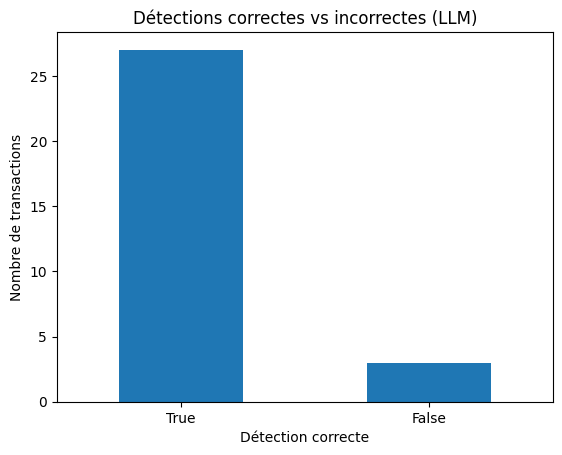

In [24]:
# Visualisation : Correct vs Incorrect
results_df["detection_correcte"].value_counts().plot(kind="bar")
plt.title("Détections correctes vs incorrectes (LLM)")
plt.xlabel("Détection correcte")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=0)
plt.show()


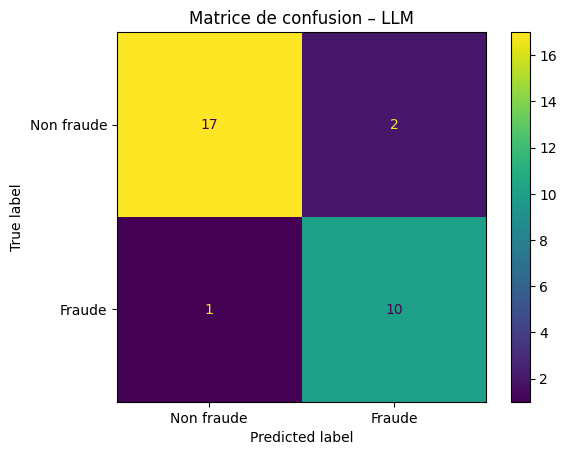

In [25]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    results_df["is_fraud_label"],
    results_df["llm_prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non fraude", "Fraude"]
)

disp.plot()
plt.title("Matrice de confusion – LLM")
plt.show()


In [26]:
results_df

,index,sender_account,amount,is_fraud_label,llm_reasoning,llm_prediction,detection_correcte
0,13,ACC559278,8.88,True,### Analyse de la transaction\n\n#### 1. Analy...,1,True
1,39,ACC512302,8.48,False,### Analyse de la transaction\n\n#### 1. Analy...,0,True
2,30,ACC464079,321.15,False,### Analyse de la transaction : ACC464079\n\n#...,1,False
3,45,ACC177625,153.50,True,### Analyse de la transaction\n\n#### 1. Analy...,1,True
4,17,ACC161098,29.11,False,### Analyse de la transaction\n\n#### 1. Analy...,0,True
5,48,ACC719749,24.34,False,### Analyse de la transaction\n\n#### 1. Analy...,0,True
6,26,ACC526588,10.46,False,### Analyse de la transaction\n\n#### 1. Analy...,0,True
7,25,ACC589928,1087.58,True,### Analyse de la transaction\n\n#### 1. Analy...,0,False
8,32,ACC459078,154.68,False,### Analyse de la transaction\n\n#### 1. Analy...,1,False
9,19,ACC327049,1369.59,True,### Analyse de la transaction\n\n#### 1. Analy...,1,True


In [27]:
# Métriques du LLM
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Supprimer les lignes non parsées
valid_df = results_df.dropna(subset=["llm_prediction"]).copy()
valid_df["is_fraud_label"]  = valid_df["is_fraud_label"].astype(int)
valid_df["llm_prediction"]  = valid_df["llm_prediction"].astype(int)

y_true = valid_df["is_fraud_label"]
y_pred = valid_df["llm_prediction"]

llm_accuracy  = accuracy_score(y_true, y_pred)
llm_precision = precision_score(y_true, y_pred, zero_division=0)
llm_recall    = recall_score(y_true, y_pred, zero_division=0)
llm_f1        = f1_score(y_true, y_pred, zero_division=0)

print("=" * 52)
print("   LLM DeepSeek-R1 — Chain-of-Thought + RAG")
print("=" * 52)
print(f"  Accuracy  : {llm_accuracy:.4f}")
print(f"  Precision : {llm_precision:.4f}")
print(f"  Recall    : {llm_recall:.4f}")
print(f"  F1-Score  : {llm_f1:.4f}")
print(f"\n  Transactions analysées : {len(valid_df)} / {len(results_df)}")
print()
print(classification_report(y_true, y_pred,
                             target_names=["Non Fraude", "Fraude"],
                             zero_division=0))

   LLM DeepSeek-R1 — Chain-of-Thought + RAG
  Accuracy  : 0.9000
  Precision : 0.8333
  Recall    : 0.9091
  F1-Score  : 0.8696

  Transactions analysées : 30 / 30

              precision    recall  f1-score   support

  Non Fraude       0.94      0.89      0.92        19
      Fraude       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.89      0.90      0.89        30
weighted avg       0.90      0.90      0.90        30



In [30]:
# Tableau comparatif
# Valeurs issues du notebook Kaggle (XGBoost + Optuna, test set 1M transactions)
# Source : classification_report + confusion matrix du notebook Kaggle
xgb_accuracy  = 0.2925
xgb_precision = 0.0436   # classe Fraude uniquement
xgb_recall    = 0.8942   # classe Fraude uniquement
xgb_f1        = 0.0832   # classe Fraude uniquement

df_compare = pd.DataFrame({
    "Modèle":     ["XGBoost + Optuna",
                   "LLM DeepSeek-R1"],
    "Accuracy":   [xgb_accuracy,  llm_accuracy],
    "Precision":  [xgb_precision, llm_precision],
    "Recall":     [xgb_recall,    llm_recall],
    "F1-Score":   [xgb_f1,        llm_f1],
    "Nb. transactions": ["1 000 000", str(len(valid_df))],
})

print("=" * 75)
print("             COMPARAISON — LLM vs XGBoost + Optuna")
print("=" * 75)
print(df_compare.to_string(index=False))

             COMPARAISON — LLM vs XGBoost + Optuna
          Modèle  Accuracy  Precision   Recall  F1-Score Nb. transactions
XGBoost + Optuna    0.2925   0.043600 0.894200  0.083200        1 000 000
 LLM DeepSeek-R1    0.9000   0.833333 0.909091  0.869565               30


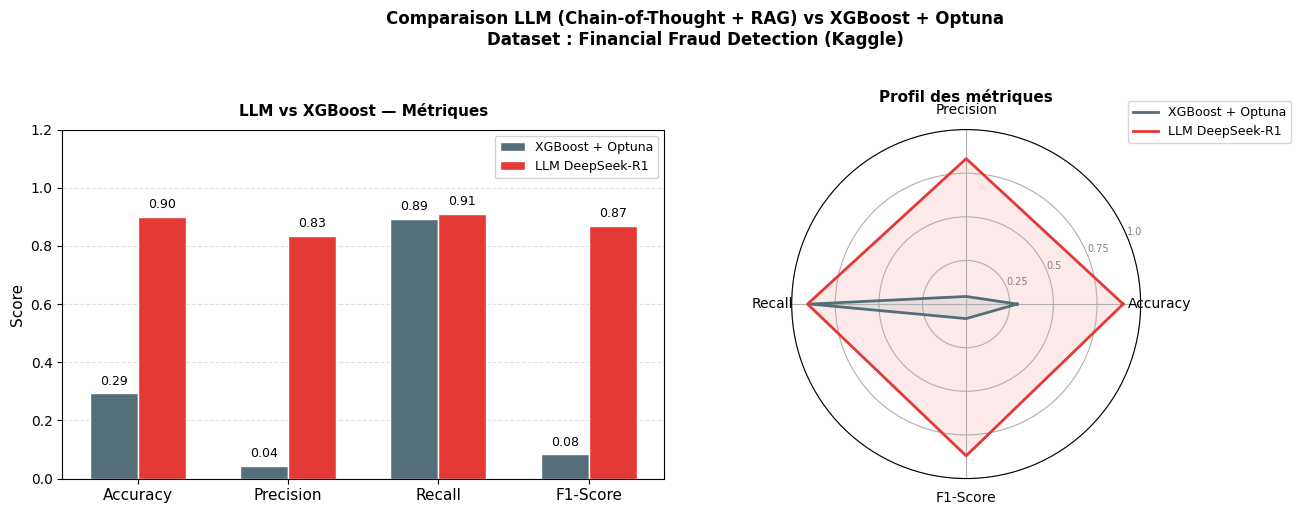

In [29]:
# Visualisation : barres + radar

metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
xgb_vals  = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]
llm_vals  = [llm_accuracy, llm_precision, llm_recall, llm_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barres groupées ────────────────────────────────────────
x     = np.arange(len(metrics))
width = 0.32

b1 = axes[0].bar(x - width/2, xgb_vals, width,
                 label="XGBoost + Optuna",
                 color="#546E7A", edgecolor="white")
b2 = axes[0].bar(x + width/2, llm_vals, width,
                 label="LLM DeepSeek-R1",
                 color="#E53935", edgecolor="white")

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            axes[0].text(bar.get_x() + bar.get_width() / 2,
                         h + 0.02, f"{h:.2f}",
                         ha="center", va="bottom", fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel("Score", fontsize=11)
axes[0].set_title("LLM vs XGBoost — Métriques",
                  fontsize=11, fontweight="bold", pad=10)
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].yaxis.grid(True, linestyle="--", alpha=0.4)
axes[0].set_axisbelow(True)

# ── Radar chart ────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2, polar=True)
axes[1].remove()

N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for vals, color, label in [
    (xgb_vals, "#546E7A", "XGBoost + Optuna"),
    (llm_vals, "#E53935", "LLM DeepSeek-R1"),
]:
    v = vals + vals[:1]
    ax2.plot(angles, v, linewidth=2, color=color, label=label)
    ax2.fill(angles, v, alpha=0.10, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=7, color="grey")
ax2.set_title("Profil des métriques", fontsize=11,
              fontweight="bold", pad=20)
ax2.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1), fontsize=9)

plt.suptitle(
    "Comparaison LLM (Chain-of-Thought + RAG) vs XGBoost + Optuna\n"
    "Dataset : Financial Fraud Detection (Kaggle)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("comparison_llm_vs_xgb.png", dpi=150, bbox_inches="tight")
plt.show()